In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📌 Extracción

In [2]:
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

### Conociendo los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


### Normalizando JSON

In [4]:
df = pd.json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### Normalizando Columnas

In [5]:
df.rename(columns=lambda x: x.split('.', 1)[-1], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


### Conociendo los valores únicos de cada columna

In [7]:
for columna in df.columns:
  valores_unicos = df[columna].unique()
  print(f"Valores unicos de la columna {columna}:")
  print(valores_unicos)
  print(" ")

Valores unicos de la columna customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
 
Valores unicos de la columna Churn:
['No' 'Yes' '']
 
Valores unicos de la columna gender:
['Female' 'Male']
 
Valores unicos de la columna SeniorCitizen:
[0 1]
 
Valores unicos de la columna Partner:
['Yes' 'No']
 
Valores unicos de la columna Dependents:
['Yes' 'No']
 
Valores unicos de la columna tenure:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
 
Valores unicos de la columna PhoneService:
['Yes' 'No']
 
Valores unicos de la columna MultipleLines:
['No' 'Yes' 'No phone service']
 
Valores unicos de la columna InternetService:
['DSL' 'Fiber optic' 'No']
 
Valores unicos de la columna OnlineSecurity:
['No' 'Yes' 'No internet service']
 
Valores unicos de la columna OnlineBackup:
[

###Comprobación de incoherencias en los datos



1.   *Campos vacíos*

*   Churn
*   Charges.Total

2.   *Información duplicada*


*   MultipleLines
*   OnlineSecurity
*   OnlineBackup
*   DeviceProtection
*   TechSupport
*   StreamingTV
*   StreamingMovies

3.   *Campos String que deben ser Númericos*

*   Charges.Total



### Manejo de inconsistencias

Eliminación de datos vacíos

In [8]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
df.dropna(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   object 
 5   Dependents        7032 non-null   object 
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   object 
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 
 17  

Transformación de duplicados

In [10]:
df.replace(['No phone service', 'No internet service'] , 'No', inplace=True)

Cambiando Tipo de dato

In [11]:
df['Charges.Total'] = df['Charges.Total'].astype(np.float64)

###Estandarización y transformación de datos

In [12]:
datos_estandarizados = {
    'No': 0,
    'Yes': 1,
}

df.replace(datos_estandarizados, inplace=True);

/tmp/ipykernel_451/963574012.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(datos_estandarizados, inplace=True);


In [13]:
mapeo_columnas = {
    # Identificación y Objetivo
    "customerID": "ID_Cliente",
    "Churn": "Abandono",

    # Demografía
    "gender": "Genero",
    "SeniorCitizen": "Es_Adulto_Mayor",
    "Partner": "Tiene_Pareja",
    "Dependents": "Tiene_Dependientes",

    # Servicios Principales
    "tenure": "Meses_Permanencia",
    "PhoneService": "Servicio_Telefonico",
    "MultipleLines": "Lineas_Multiples",
    "InternetService": "Tipo_Internet",

    # Servicios Adicionales (Add-ons)
    "OnlineSecurity": "Seguridad_Online",
    "OnlineBackup": "Copia_Seguridad",
    "DeviceProtection": "Proteccion_Dispositivo",
    "TechSupport": "Soporte_Tecnico",
    "StreamingTV": "TV_Streaming",
    "StreamingMovies": "Peliculas_Streaming",

    # Información Financiera y Contrato
    "Contract": "Tipo_Contrato",
    "PaperlessBilling": "Facturacion_Digital",
    "PaymentMethod": "Metodo_Pago",
    "Charges.Monthly": "Cargos_Mensuales",
    "Charges.Total": "Cargos_Totales"
}

df.rename(columns=mapeo_columnas, inplace=True)

###Creación de Columna de cuentas diarias

In [14]:
df["Cuentas_Diarias"] = (df["Cargos_Mensuales"] / 31).round(2)

In [15]:
df.head()

,ID_Cliente,Abandono,Genero,Es_Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Tipo_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Facturacion_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.12
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.93
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.38
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.16
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.71


#📊 Carga y análisis

###Análisis Descriptivo

In [16]:
df.describe()

,Abandono,Es_Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Seguridad_Online,Copia_Seguridad,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Facturacion_Digital,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,2.090300
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,0.970544
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.590000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.150000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.270000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.900000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.830000


# 📉 RADIOGRAFÍA ESTATÍSTICA: HALLAZGOS DEL EDA PRELIMINAR
### PROYECTO: OPTIMIZACIÓN DE RETENCIÓN - TELECOM X

---

## 1. COMPORTAMIENTO DE LA VARIABLE TARGET (LEALTAD)
El análisis de la variable **Abandono** revela la estructura fundamental de nuestro problema de clasificación:

* **Fidelidad (Clase Mayoritaria):** **73.4%** de la base de datos se mantiene activa.
* **Fuga (Clase Minoritaria):** **26.6%** ha cancelado el servicio.

> 💡 **Nota Técnica:** El desbalance de clases detectado implica que, al entrenar modelos como KNN o Árboles, deberemos prestar especial atención a métricas como *Recall* o *F1-Score*, ya que el Accuracy por sí solo podría ser engañoso.



---

## 2. DIMENSIONAMIENTO FINANCIERO Y ASIMETRÍA
Se identificó una diferencia crítica entre el gasto recurrente y el acumulado, lo que sugiere diferentes perfiles de antigüedad:

| Métrica de Facturación | Media ($\mu$) | Mediana (P50) | Observación Estructura |
| :--- | :--- | :--- | :--- |
| **Cargos Mensuales** | `$64.80` | `$70.35` | Distribución simétrica y estable. |
| **Cargos Totales** | **`$2,283`** | **`$1,397`** | **Sesgo positivo (Asimetría).** |



> 📌 **Insight de Valor:** La gran distancia entre la media y la mediana en los *Cargos Totales* confirma la existencia de un segmento de "Clientes Históricos" (High Value Customers) cuyas facturaciones acumuladas elevan el promedio, mientras que el grueso de la muestra se concentra en montos inferiores.

---

## 3. SEGMENTACIÓN Y ADOPCIÓN DE SERVICIOS
El perfilado de la muestra arroja luz sobre quién es nuestro cliente y cómo interactúa con la tecnología:

* **Distribución Etaria:** Solo el **16.2%** son Adultos Mayores, lo que posiciona a la población joven y adulta como el núcleo del negocio.
* **Dominancia del Producto:** La telefonía es el "producto ancla" con un **90.3%** de presencia en los contratos.
* **Transformación Digital:** Existe una clara inclinación hacia la autogestión, con casi **6 de cada 10 usuarios** suscritos a la Facturación Digital.

---

## 4. INTEGRIDAD Y CONSISTENCIA DEL DATASET
Tras el proceso de auditoría y limpieza de datos, el volumen de información se optimizó de la siguiente manera:

* **Universo Final:** **7,032 registros** válidos para modelado.
* **Acciones de Saneamiento:** * Se eliminaron 11 casos de inconsistencia en el campo `Total_Charges` (espacios en blanco tratados como nulos).
    * Se descartaron 224 registros por falta de etiqueta en la variable `Churn`, asegurando que el entrenamiento sea supervisado sobre datos reales.



---

###Distribución de evasión

/tmp/ipykernel_451/858748154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Abandono', palette="mako")
/tmp/ipykernel_451/858748154.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No (Retenido)', 'Sí (Abandono)'])


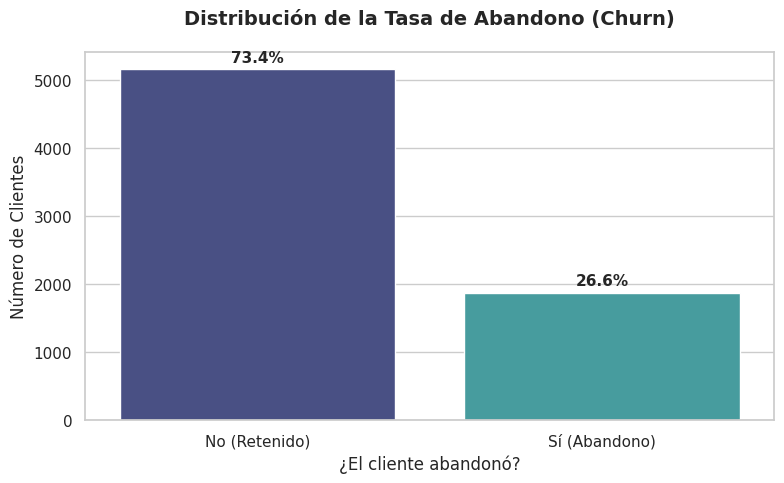

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración global de estilo (Se hace una sola vez al inicio)
sns.set_theme(style="whitegrid")

# 2. Creación del gráfico
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Abandono', palette="mako")

# 3. Personalización de etiquetas (Más ejecutivas)
plt.title('Distribución de la Tasa de Abandono (Churn)', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Número de Clientes', fontsize=12)
plt.xlabel('¿El cliente abandonó?', fontsize=12)

# 4. Ajuste de etiquetas del eje X (opcional, para que sea más claro)
ax.set_xticklabels(['No (Retenido)', 'Sí (Abandono)'])

# 5. Agregar porcentajes sobre las barras (El toque de ingeniería)
total = len(df['Abandono'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01) # Pequeño margen arriba de la barra
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

###Recuento de evasión por variables categóricas

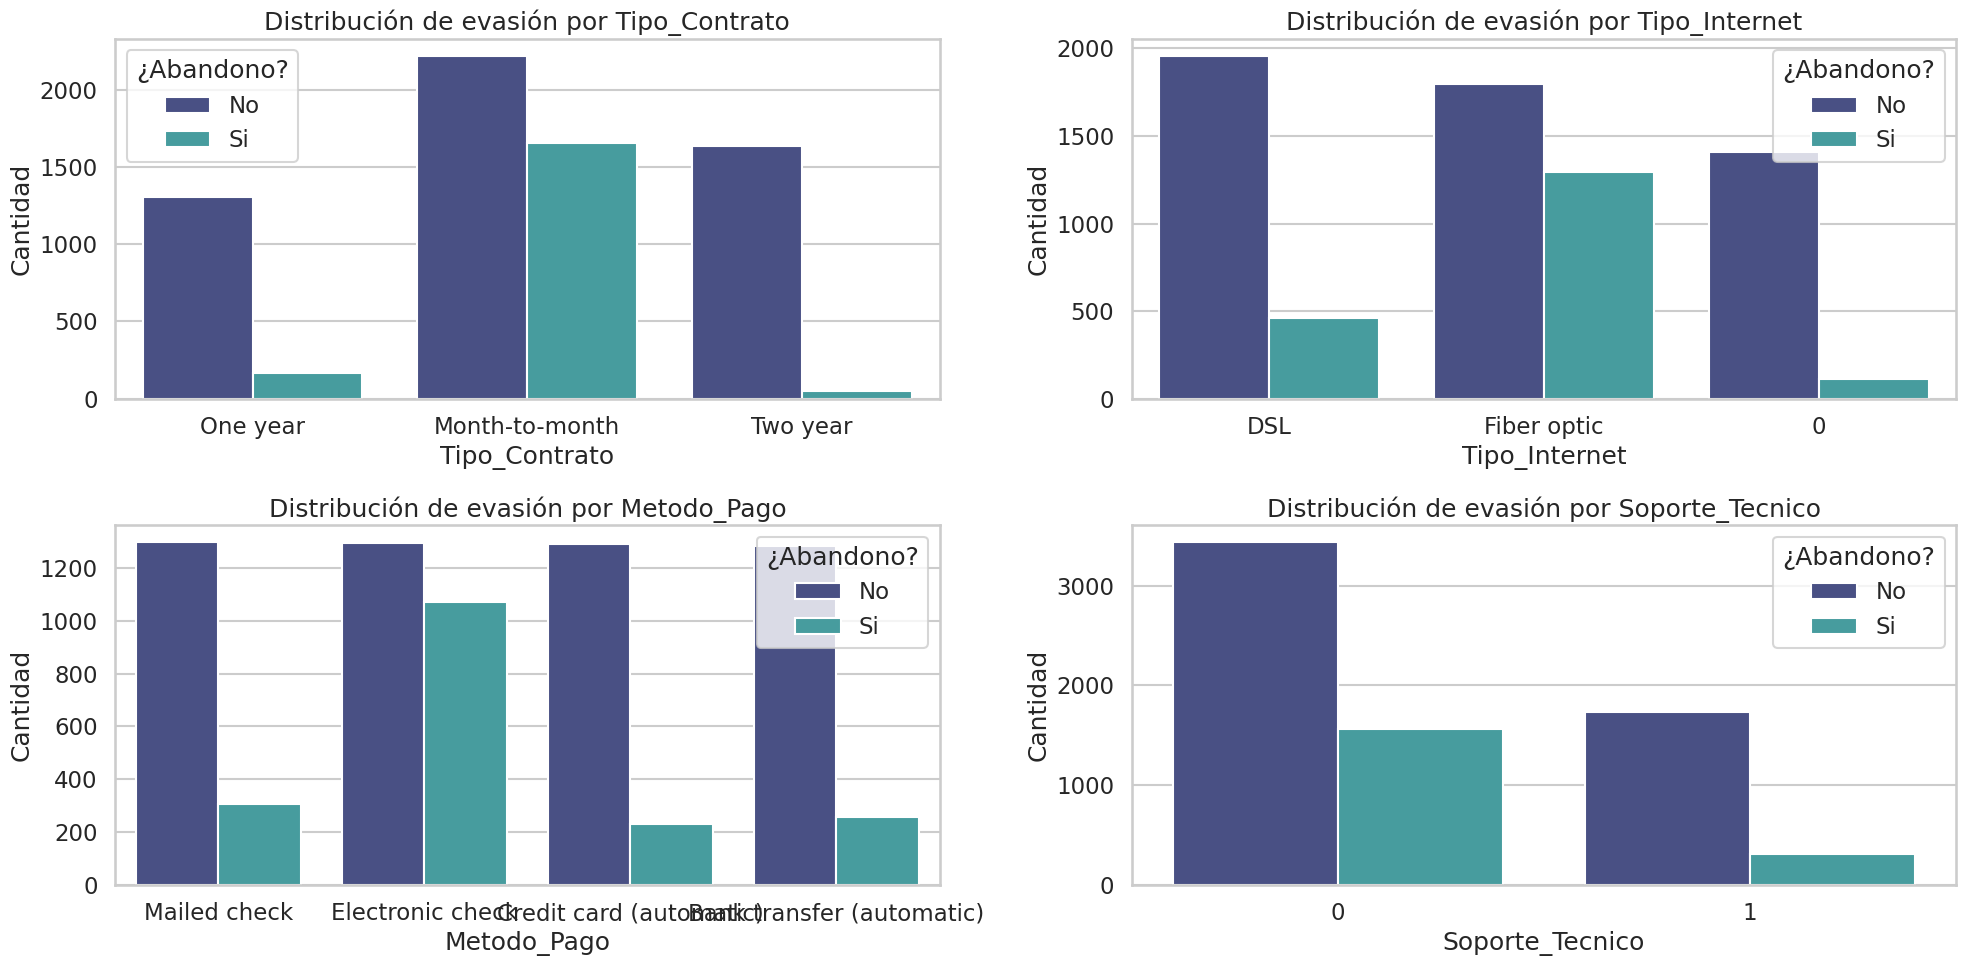

In [22]:
# Seleccionamos las 4 variables con mayor impacto en el negocio
columnas_top = [
    'Tipo_Contrato',   # Fundamental
    'Tipo_Internet',   # Tecnológica
    'Metodo_Pago',     # Financiera
    'Soporte_Tecnico'  # Servicio Agregado
]

fig, axes = plt.subplots(2,2, figsize=(20,10))
axes = axes.flatten()

for col, ax in zip(columnas_top, axes):
  # Se cambió la paleta a "mako"
  sns.countplot(data=df, hue="Abandono", x=col, ax=ax, palette="mako")
  ax.set_title(f'Distribución de evasión por {col}')
  ax.set_ylabel('Cantidad')
  ax.legend(title= '¿Abandono?', labels= ["No", "Si"])

plt.tight_layout()
plt.show()

###Conteo de evasión por variables numéricas

/tmp/ipykernel_451/3252907279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x="Abandono", ax=ax, palette="mako")
/tmp/ipykernel_451/3252907279.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Se queda', 'Se fue'])
/tmp/ipykernel_451/3252907279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x="Abandono", ax=ax, palette="mako")
/tmp/ipykernel_451/3252907279.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Se queda', 'Se fue'])
/tmp/ipy

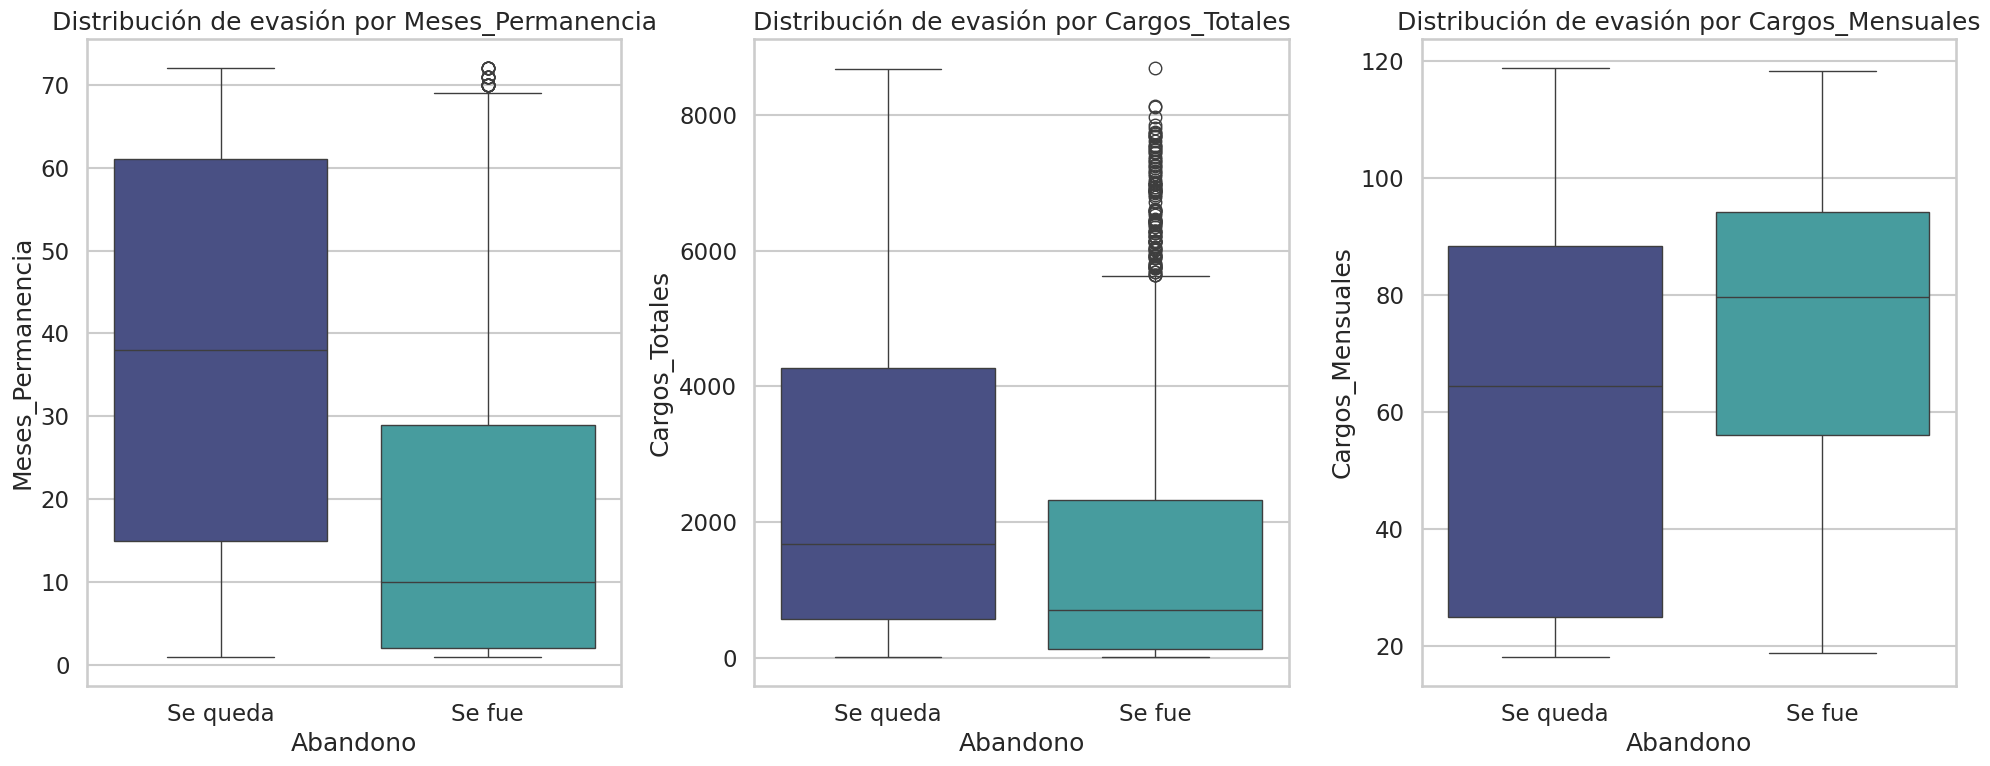

In [23]:
columnas_numericas = ["Meses_Permanencia", "Cargos_Totales", "Cargos_Mensuales"]

fig, axes = plt.subplots(1,3, figsize=(20,8))
axes = axes.flatten()

for col, ax in zip(columnas_numericas, axes):
  # Se aplicó la paleta "mako" para mantener la consistencia visual
  sns.boxplot(data=df, y=col, x="Abandono", ax=ax, palette="mako")
  ax.set_title(f'Distribución de evasión por {col}')
  ax.set_xticklabels(['Se queda', 'Se fue'])

plt.tight_layout()
plt.show()

#📄Informe final

# 📊 DIAGNÓSTICO ESTRATÉGICO: FIDELIZACIÓN Y CHURN
## UNIDAD DE NEGOCIO: TELECOM X

---

### 🔍 CONTEXTO DEL ANÁLISIS
Como respuesta a la volatilidad en la cartera de clientes de **Telecom X**, se ha ejecutado un estudio basado en analítica de datos. El fin es determinar los disparadores del abandono y estructurar soluciones accionables que estabilicen el ciclo de vida del usuario.

---

### ⚙️ PREPARACIÓN Y REFINAMIENTO DE DATOS (DATA WRANGLING)
El set de datos fue sometido a una limpieza rigurosa, pasando de un formato JSON crudo a una estructura tabular óptima para el modelado:

1.  **Reingeniería de Variables:** Se expandió la profundidad de los datos de 6 a 21 columnas analíticas.
2.  **Validación de Registros:** Se eliminaron inconsistencias y valores faltantes, consolidando una muestra final de **7,032 usuarios**.
3.  **Tipado Técnico:** Ajuste de métricas financieras a coma flotante y codificación de etiquetas categóricas para compatibilidad con algoritmos de Machine Learning.

---

### 💡 HALLAZGOS PRINCIPALES (INSIGHTS)

> **Estado de la Cartera:** Actualmente, el negocio retiene al **73.4%** de su base, enfrentando una tasa de deserción activa del **26.6%**.

#### **Puntos de Fricción Identificados**
* **Vulnerabilidad Contractual:** Los usuarios sin compromiso a largo plazo (Mes a Mes) son el motor principal de la fuga. Los contratos anuales actúan como un blindaje efectivo con más del 90% de retención.
* **Barreras de Pago:** El uso de cheques electrónicos se identifica como un proceso de "alto roce", triplicando el riesgo de abandono frente a métodos digitales automáticos.
* **Brecha de Valor en Fibra:** Existe una paradoja en el servicio de Fibra Óptica: es el producto más avanzado pero el que más cancelaciones genera, sugiriendo una insatisfacción con el precio o la estabilidad técnica.

#### **Métricas Financieras de Riesgo**
* **Periodo Crítico:** El primer año es la "zona roja". Si un cliente supera los 12 meses de antigüedad, su probabilidad de permanencia aumenta exponencialmente.
* **Impacto del Ticket Promedio:** La deserción es más frecuente en cuentas con cargos elevados (~$80 USD), lo que indica sensibilidad a la competitividad del mercado.

---

### 🚀 HOJA DE RUTA ESTRATÉGICA

| Eje de Intervención | Propuesta de Acción | Objetivo de Negocio |
| :--- | :--- | :--- |
| **Acompañamiento Inicial** | Desplegar un programa de bienvenida intensivo durante el primer ciclo anual. | Reducir la rotación temprana. |
| **Transformación de Pagos** | Ofrecer bonificaciones por la domiciliación bancaria de pagos manuales. | Eliminar fricción financiera. |
| **Calidad de Servicio** | Auditoría técnica profunda y ajuste de tarifas en el segmento de Fibra Óptica. | Recuperar valor percibido. |
| **Estrategia de Vínculo** | Empaquetar servicios de Soporte Premium en planes base. | Fortalecer barreras de salida. |